In [264]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
import magic
import time
import os
import sys
import torch
from skimage import io as imio
import torch.optim as optim
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

sys.path.append('2D_gastruloids_v5')
import fns_plotting_scripts as fns_plot
import fns_NN
import IIF_analysis as IIF

import importlib
importlib.reload(IIF);

In [72]:
# Load all three datasets
config = IIF.ExperimentConfig(
    exp_params = {
        'Z2': ('250930_Perturbation6i_MEKi_WntSeci', 'expZ2_data_scaled_bgsub_6_cols_251002.csv',
               {'SOX17_1': 'SOX17', 'TBX6_2': 'TBX6', 'SOX2_2': 'SOX2', 'DAPI_1': 'DAPI'},
               ['B50', 'B50I5', 'B50SB10', 'B50M0p5'],
               {'ISL1': 200, 'TFAP2C': 350, 'SOX17': 200, 'NANOG': 800, 'TBX6': 300, 'TBXT': 175, 'SOX2': 150},
               'expZ2_junk_labels_nans_removed.csv'),
        'X7': ('250909_Perturbation6i_LATSi', 'expX7_data_scaled_bgsub_4_cols_250909.csv',
               {'SOX17_1': 'SOX17', 'DAPI_1': 'DAPI'},
               ['B50', 'B50T30'],
               {'ISL1': 150, 'TFAP2C': 400, 'SOX17': 200, 'NANOG': 600, 'TBX6': 400, 'TBXT': 175, 'SOX2': 250},
               None),
        '20': ('250509_Exp20', 'exp20_data_bgsub_scaled_250509.csv',
               {'SOX17_1': 'SOX17', 'DAPI_1': 'DAPI'},
               ['B50', 'B200', 'B10'],
               {'ISL1': 500, 'GATA3': 700, 'HAND1': 500, 'CDX2': 600, 'TFAP2C': 600, 'SOX17': 500, 'PRDM1': 650,
                'SNAI1': 300, 'MIXL1': 400, 'EOMES': 200, 'TBXT': 285, 'TBX6': 375, 'OCT4': 500, 'NANOG': 1600,
                'SOX2': 400, 'OTX2': 400},
               None),
    },
    signal_names  = ['pSMAD1', 'ncYAP', 'BCat', 'LEF1', 'ncSMAD23', 'cytopERK'],
    feature_names = ['nucArea', 'nucVolume', 'nucMajorAxis', 'nucMinorAxis',
                     'nucCircularity', 'CircleEdgeDist', 'RadialDist']
)


exp_result_20 = IIF.ExperimentResults('20', config)
exp_result_Z2 = IIF.ExperimentResults('Z2', config)
exp_result_X7 = IIF.ExperimentResults('X7', config)

B50, Nbins = 609
B200, Nbins = 576
B10, Nbins = 503
B50, Nbins = 609
B200, Nbins = 576
B10, Nbins = 503
B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 544
B50T30, Nbins = 340
B50, Nbins = 544
B50T30, Nbins = 340


In [265]:
# determine intensity limits based on control
coli = 2
markers = ['ISL1', 'TFAP2C', 'SOX17', 'NANOG', 'TBX6_2', 'TBXT', 'SOX2_2']
Ilim = dict();

for m in markers+['DAPI']:
    fname = IIF.getImageFilename(coli, m, dataDir, rdStr = 'Rd')
    im = imio.imread(fname)
    if m == 'TBX6_2':
        Imin, Imax = np.percentile(im[im>0], [80,99])
    elif m == 'TFAP2C':
        Imin, Imax = np.percentile(im[im>0], [1,97])
    else:    
        Imin, Imax = np.percentile(im[im>0], [1,99])
    Ilim[m] = [Imin,Imax]

loading Z:/Shared-03/BF/250930_Perturbation6iExpZ2_set2_120k_ESI17_7Rds\250925_Perturbation6iExpZ2_set2_120k_ESI17_Rd2_SMAD23_SOX17_LEF1_MP42\MIP\stitched_MIP_p0018_w0002_t0000.tif
loading Z:/Shared-03/BF/250930_Perturbation6iExpZ2_set2_120k_ESI17_7Rds\250927_Perturbation6iExpZ2_set2_120k_ESI17_Rd4_TFAP2C_TBX6_pAKT_MP42\MIP\stitched_MIP_p0018_w0001_t0000.tif
loading Z:/Shared-03/BF/250930_Perturbation6iExpZ2_set2_120k_ESI17_7Rds\250930_Perturbation6iExpZ2_set2_120k_ESI17_Rd7_SOX2_MP42\MIP\stitched_MIP_p0018_w0001_t0000.tif


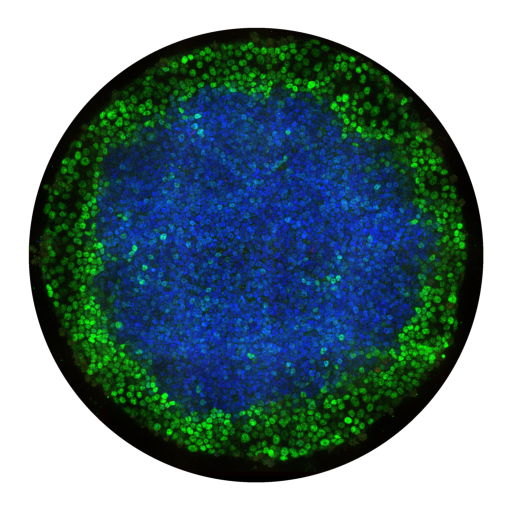

In [267]:
# example channel overlay
colID = 19
#stains = signal_names_simplified 
stains = ['SOX17', 'TFAP2C', 'SOX2_2']
dataDir = 'Z:/Shared-03/BF/250930_Perturbation6iExpZ2_set2_120k_ESI17_7Rds'
overlay_markers = [None]
for ov in overlay_markers:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
    overlay_marker = ov
    
    RGBbase, image_meta = IIF.makeRGBbase(exp_result_Z2.col, colID, stains, dataDir, outer_margin=100, crop_margin= 140, center_x_margin = 0, center_y_margin = -0, 
                                Ilim = Ilim, rdStr='Rd')
    
    ax.imshow(RGBbase);
    ax.axis('off');

    import imageio
    #imageio.imwrite(dataDir + f'/B50M0p5_SOX17_TFAP2C_SOX2.png', RGBoverlay)

In [ ]:
percentiles= {'pSMAD1': [50, 99],
 'YAP': [1, 99.5],
 'BCat': [0.1, 99],
 'LEF1': [1, 99],
 'SMAD23': [1, 99],
 'pERK': [5, 99],
 'pAKT': [10, 99],
 'SMAD2': [1, 99],
 'ISL1': [1, 99],
 'GATA3': [1, 99],
 'HAND1': [1, 99],
 'CDX2': [1, 99],
 'TFAP2C': [1, 99],
 'SOX17': [1, 99],
 'PRDM1': [90, 99.5],
 'SNAI1': [1, 99],
 'MIXL1': [1, 99],
 'EOMES': [1, 99],
 'TBXT': [1, 99],
 'TBX6': [70, 99],
 'OCT4': [1, 99],
 'NANOG': [40, 99],
 'SOX2': [1, 99],
 'SOX2_2': [1, 99],
 'OTX2': [1, 99],
 'DAPI': [1, 99]}

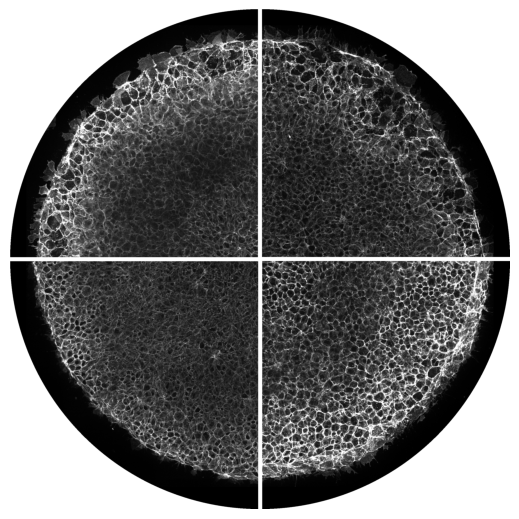

In [38]:
# Plot four-way colony images
overlay_configs = [
    # (col_dict,  col_id, ref_col, center_x_margin, center_y_margin, data_dir)
    (exp_result_Z2.col,  19, 2,  30,   -80,  'Z:/Shared-03/BF/250930_Perturbation6iExpZ2_set2_120k_ESI17_7Rds'),
    (exp_result_X7.col,   8, 2,   0,    0,   'Z:/Shared-03/BF/250502_Perturbation6iExpX7_100kESI17_6Rds/data'),
    (exp_result_Z2.col,   8, 2, -30,   40,   'Z:/Shared-03/BF/250930_Perturbation6iExpZ2_set2_120k_ESI17_7Rds'),
    (exp_result_Z2.col,   2, 2,   0,  -20,   'Z:/Shared-03/BF/250930_Perturbation6iExpZ2_set2_120k_ESI17_7Rds'),
]

# Unpack for IIF function
cols              = [c[0] for c in overlay_configs]
colis             = [c[1] for c in overlay_configs]
ref_cols          = [c[2] for c in overlay_configs]
center_x_margins  = [c[3] for c in overlay_configs]
center_y_margins  = [c[4] for c in overlay_configs]
dataDirs = [c[5] for c in overlay_configs]


import imageio
import importlib
importlib.reload(IIF)

for marker in ['BCat']:
    RGBoverlay = IIF.makeRGBoverlay_colisectors(
        cols=cols, colis=colis, marker=marker,
        dataDirs=dataDirs,
        crop_margin=70, reference_cols=ref_cols,
        center_x_margins=center_x_margins,
        center_y_margins=center_y_margins,
        percentiles=percentiles,
        outer_margin=80
    )
    
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(RGBoverlay)
    ax.axis('off')
    ax.set_aspect('equal')
    plt.tight_layout(pad=0)
    
    imageio.imwrite(
        f'Fig5/four_cond_overview_{marker}_MIPs.png',
        RGBoverlay
    )
    plt.show()

In [74]:
sigs_to_plot = signal_names
# Normalize and create experiments
data_norm_Z2, _, _ = IIF.normalize_to_ctrl_profile(
    exp_result_Z2.data_z, exp_result_Z2.exp_z, sigs_to_plot
)
data_norm_X7, _, _ = IIF.normalize_to_ctrl_profile(
    exp_result_X7.data_z, exp_result_X7.exp_z, sigs_to_plot
)

col_norm_Z2, exp_norm_Z2 = IIF.create_experiment(data_norm_Z2, exp_result_Z2.meta, exp_result_Z2.feature_names)
col_norm_X7, exp_norm_X7 = IIF.create_experiment(data_norm_X7, exp_result_X7.meta, exp_result_X7.feature_names)

plot_configs_norm = [
    (exp_norm_Z2, 'B50',     'Z2 ctrl'),
    (exp_norm_Z2, 'B50I5',   'Z2 IWP2'),
    (exp_norm_Z2, 'B50M0p5', 'Z2 MEKi'),
    (exp_norm_X7, 'B50T30',  'X7 TRULI'),
]

B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 544
B50T30, Nbins = 340


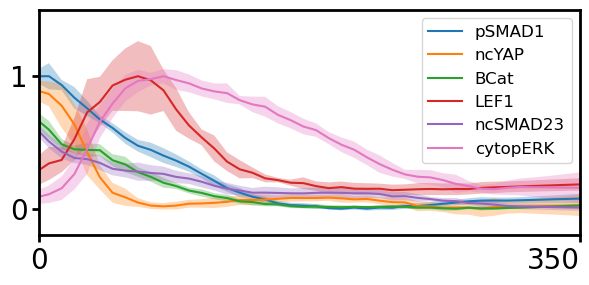

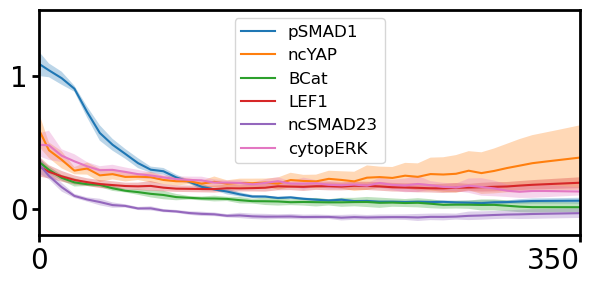

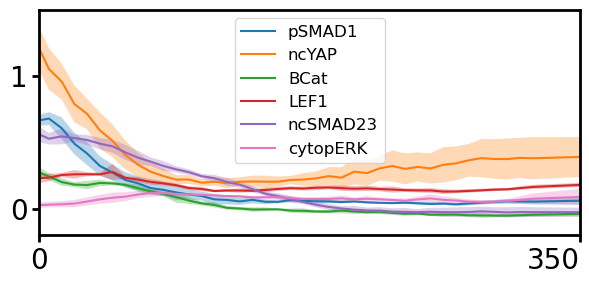

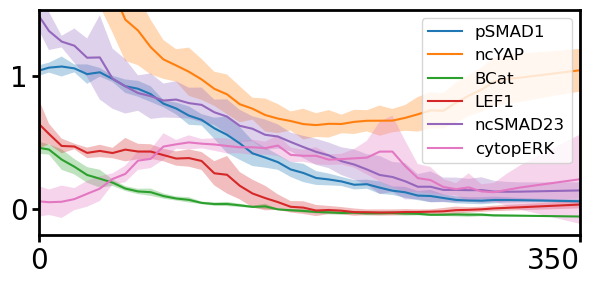

In [107]:
# Plot signaling profiles
fs = 16
fs_ticks = 20
sw = 2

for legend in [True]:
    suffix = '_legend' if legend else ''
    
    for exp_norm, cond, label in plot_configs_norm:
        
        fig, ax = plt.subplots(figsize=(6, 3))  # match fate_histogram figsize
        
        handles = []
        for s in sigs_to_plot:
            h = exp_norm.plotRadialProfiles(
                s, cond, mode='colonies', sigma=1,
                color=color_dict[s], ax=ax
            )
            handles.append(h)
        
        ax.set_xlabel('', fontsize=fs)
        ax.set_ylabel('', fontsize=fs)
        ax.set_ylim(-0.2, 1.5)
        
        ax.set_xticks([0, 350])
        ax.set_xticklabels(['0', '350'], fontsize=fs_ticks)
        
        # Center '0' under its tick, right-align '350' under its tick
        ax.xaxis.get_major_ticks()[0].label1.set_horizontalalignment('center')
        ax.xaxis.get_major_ticks()[1].label1.set_horizontalalignment('right')
        ax.set_box_aspect(1/2.4)  # match fate_histogram aspect ratio
        
        for spine in ax.spines.values():
            spine.set_linewidth(sw)
        
        ax.tick_params(axis='x', labelsize=fs_ticks, width=sw, length=5)
        ax.tick_params(axis='y', labelsize=fs_ticks, width=sw, length=5)
        
        y_min, y_max = ax.get_ylim()
        ax.set_yticks(np.arange(int(np.ceil(y_min)), int(np.floor(y_max)) + 1, 1))
        
        if legend:
            ax.legend(handles=handles, labels=sigs_to_plot, fontsize=12)
        
        plt.tight_layout()
        plt.savefig(
            f'Fig5/signaling_profiles_{label}{suffix}.png', dpi=150, bbox_inches='tight'
        )
        plt.show()
        plt.close()

In [209]:
# Load Exp20 data for VIB predictions
exp_result    = exp_result_20
meta_pert     = copy.deepcopy(exp_result.meta)
meta_pert.conditions = ['B50']
hyperparam    = {'HIDDEN_DIM': 32, 'N_LAYERS': 2, 'LATENT_DIM': 2}

PERTURB_KWARGS = dict(
    perturbing_sigs=['cytopERK'], perturb_mode='inh',
    percentile=5, k_nn=5, preserve_signals= ['pSMAD1']
)

# Smooth B50 data
data_B50_20  = exp_result.data[exp_result.data['condition'] == 'B50'].copy()
data_smoothed = data_B50_20.copy()
data_smoothed[exp_result.signal_names] = IIF.apply_smoothing(
    data_B50_20[exp_result.signal_names].values, k_val=10, mode='gaussian'
)

In [210]:
# Thresholds
threshold= IIF.determine_threshold(
    data_B50_20, **{k: PERTURB_KWARGS[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']}
)

threshold_smoothed= IIF.determine_threshold(
    data_smoothed, **{k: PERTURB_KWARGS[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']}
)
# Naive and KNN perturbations
data_naive, data_naive_z    = IIF.create_perturbed_data(
    data_B50_20,  exp_result.signal_names, PERTURB_KWARGS['perturbing_sigs'],
    threshold, perturb_mode=PERTURB_KWARGS['perturb_mode'], do_naive=True,
    preserve_signals=PERTURB_KWARGS['preserve_signals']
)
data_knn,   data_knn_z   = IIF.create_perturbed_data(
    data_smoothed, exp_result.signal_names, PERTURB_KWARGS['perturbing_sigs'],
    threshold_smoothed, perturb_mode=PERTURB_KWARGS['perturb_mode'], do_naive=False,
    k_nn=PERTURB_KWARGS['k_nn'], preserve_signals=PERTURB_KWARGS['preserve_signals']
)

col_knn_z, exp_knn_z = IIF.create_experiment(data_knn_z, meta_pert, exp_result.feature_names)

B50, Nbins = 609


In [211]:
# Make VIB predictions based on naive and projected signaling
_, avg_pred_naive, predictions_naive = IIF.run_vib_predictions(
    exp_result.exp_dir, data_B50_20, data_naive,
    exp_result.signal_names, exp_result.gene_names, hyperparam, N_run=3
)
_, avg_pred_knn, predictions_knn = IIF.run_vib_predictions(
    exp_result.exp_dir, data_smoothed, data_knn,
    exp_result.signal_names, exp_result.gene_names, hyperparam, N_run=3
)

col_naive_pred, _ = IIF.create_experiment(avg_pred_naive, meta_pert, exp_result.feature_names)
col_knn_pred,   _ = IIF.create_experiment(avg_pred_knn,   meta_pert, exp_result.feature_names)

load VIB
load VIB
load VIB
load VIB
load VIB
load VIB
B50, Nbins = 609
B50, Nbins = 609


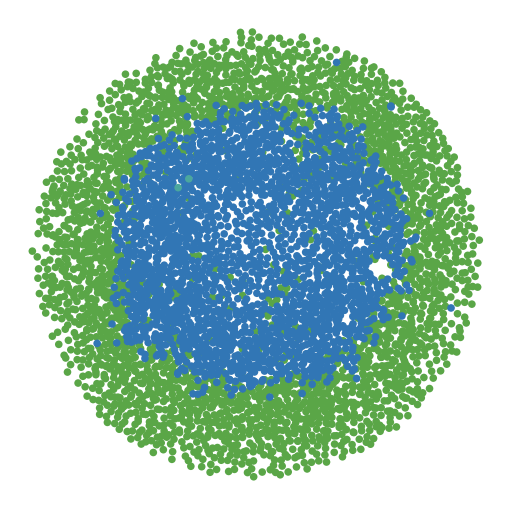

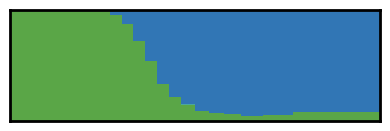

In [212]:
# Plot colony scatter + fate histogram
do_naive=False

lim = 353
col_id = 2
ms = 30

fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
if do_naive:
    col_naive_pred[col_id].scatter_fates(ms=ms, ax=ax, legend=False, thresh=exp_result_20.thresh)
    filename = f'Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_naive.png'
    data_for_hist = avg_pred_naive
    hist_filename = f'Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_naive.png'
    #mu_perturb = encode_data(vib_choice, data_naive_z, exp_result.signal_names)
else:
    col_knn_pred[col_id].scatter_fates(ms=ms, ax=ax, legend=False, thresh=exp_result_20.thresh)
    filename = f'Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_knn.png'
    data_for_hist = avg_pred_knn
    hist_filename = f'Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_knn.png'
    #mu_perturb = encode_data(vib_choice, data_knn_z, exp_result.signal_names)
    

plt.savefig(filename) 

IIF.fate_histogram(data_for_hist, exp_result_20)
plt.savefig(hist_filename)

In [ ]:
# Load models from Fig 3
signals = ['pSMAD1', 'ncYAP', 'LEF1', 'BCat', 'ncSMAD23', 'cytopERK']

hyperparam = {'HIDDEN_DIM':32, 'N_LAYERS':2, 'LATENT_DIM': 2}
genes = exp_result_20.gene_names
data = exp_result_20.data

cond = 'B50'
data_cond = data[data['condition']==cond]

feat_train = data_cond[signals] 
tar_train = data_cond[exp_result_20.gene_names]

run = 12
vib = IIF.VIB(feat_train, tar_train, hyperparam)
vib.model = torch.load(
    os.path.join(exp_result_20.exp_dir, f'modelws_12_{len(signals)}D.pth'),
    map_location='cpu', weights_only=False
)
model = vib.model

  99.0% inside contours
  99.0% inside contours


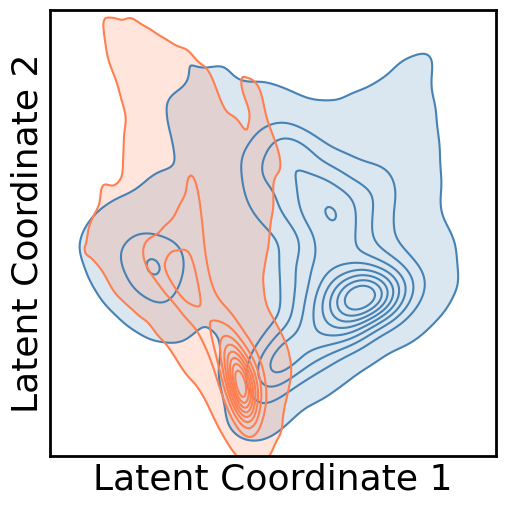

In [217]:
# load fate map
dataDir = exp_result_20.exp_dir
L1grid_scaled = np.load(dataDir + '/fatemap_L1grid_scaled.npy')
L2grid_scaled = np.load(dataDir + '/fatemap_L2grid_scaled.npy')
fates = list(np.load(dataDir + '/fatemap_fates.npy'))
L1smin, L1smax, L2smin, L2smax = np.load(dataDir + '/fatemap_limits.npy')
L1mean, L1std = np.load(dataDir + '/fatemap_L1mean_L1std.npy')
L2mean = np.load(dataDir + '/fatemap_L2mean.npy')


do_naive  = True
data_pert = data_naive_z if do_naive else data_knn_z
pert_label = f'naive' if do_naive else f'knn'
filename   = (f'Fig5/LS_fate_{len(exp_result.signal_names)}D_'
              f'{PERTURB_KWARGS["perturbing_sigs"][0]}_'
              f'{PERTURB_KWARGS["perturb_mode"]}_ctrl_vs_{pert_label}.png')

data_z = exp_result_20.data_z

# Encode both B50 and perturbed
with torch.no_grad():
    mu_perturb, _ = vib.model.encode(torch.FloatTensor(data_pert[signals].values))
    mu, _ = vib.model.encode(torch.FloatTensor(data_z[data_z['condition'] == 'B50'][signals].values))
        
mu_perturb  = mu_perturb.numpy()
L1_scaled_perturb = (mu_perturb[:, 0] - L1mean) / L1std
L2_scaled_perturb = (mu_perturb[:, 1] - L2mean) / L1std

mu = mu.numpy()
L1_scaled = (mu[:, 0] - L1mean) / L1std
L2_scaled = (mu[:, 1] - L2mean) / L1std

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

# B50 KDE
kde_grid_b50, levels_b50 = IIF.kde_on_grid(L1_scaled, L2_scaled, L1grid_scaled, L2grid_scaled)
ax.contourf(L1grid_scaled, L2grid_scaled, kde_grid_b50,
           levels=levels_b50, colors='steelblue', alpha=0.2)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_b50,
           levels=levels_b50, colors='steelblue', linewidths=1.5)


# Perturbed KDE
kde_grid_pert, levels_pert = IIF.kde_on_grid(L1_scaled_perturb, L2_scaled_perturb, L1grid_scaled, L2grid_scaled)
ax.contourf(L1grid_scaled, L2grid_scaled, kde_grid_pert,
           levels=levels_pert, colors='coral', alpha=0.2)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_pert,
           levels=levels_pert, colors='coral', linewidths=1.5)


ax.set_xlim(L1smin, L1smax)
ax.set_ylim(L2smin, L2smax)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
ax.set_aspect('equal', adjustable='box')

for spine in ax.spines.values():
    spine.set_linewidth(sw)

plt.tight_layout(pad=0.5)
plt.savefig(filename, dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()

B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
  99.0% inside contours
  99.0% inside contours


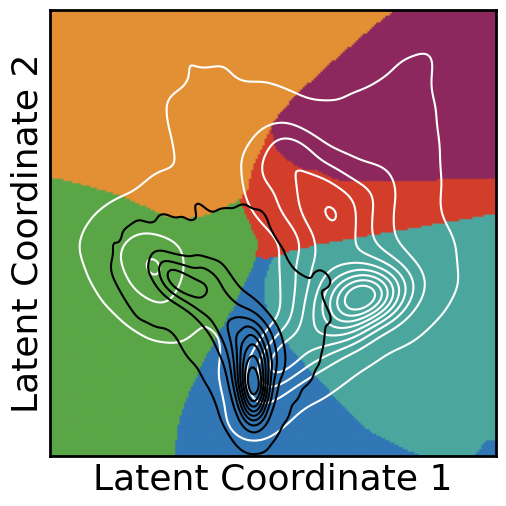

In [218]:
# precompute rgb image once
rgb_image = np.zeros((200, 200, 3))
for i, fate in enumerate(fates):
    color = IIF.colmap_fates[fate]
    rgb_image[i // 200, i % 200] = mcolors.to_rgb(color)



# Encode measured condition
exp_result_meas = ExperimentResults('Z2')
cond = 'B50M0p5'

data_B50_meas = exp_result_meas.data[exp_result_meas.data['condition'] == 'B50'].copy()
data_cond = exp_result_meas.data[exp_result_meas.data['condition'] == cond].copy()
data_cond_z  = exp_result_meas.data_z[exp_result_meas.data_z['condition'] == cond].copy()
mu_meas, _ = vib.model.encode(
    torch.FloatTensor(data_cond_z[signals].values)
)
mu_meas = mu_meas.detach().numpy()

L1_scaled_meas = (mu_meas[:, 0] - L1mean) / L1std
L2_scaled_meas = (mu_meas[:, 1] - L2mean) / L1std

filename = (f'Fig5/LS_fate_{len(exp_result.signal_names)}D_'
            f'{PERTURB_KWARGS["perturbing_sigs"][0]}_'
            f'{PERTURB_KWARGS["perturb_mode"]}_ctrl_vs_meas.png')

# Plot
fs = 26
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb_image, origin='lower', extent=[L1smin, L1smax, L2smin, L2smax])

# B50 KDE (white)
kde_grid_b50, levels_b50 = IIF.kde_on_grid(L1_scaled, L2_scaled, L1grid_scaled, L2grid_scaled)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_b50,
           levels=levels_b50, colors='white', linewidths=1.5)

# Measured KDE (black)
kde_grid_meas, levels_meas = IIF.kde_on_grid(L1_scaled_meas, L2_scaled_meas, L1grid_scaled, L2grid_scaled)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_meas,
           levels=levels_meas, colors='black', linewidths=1.5)

ax.set_xlim(L1smin, L1smax)
ax.set_ylim(L2smin, L2smax)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
ax.set_aspect('equal', adjustable='box')

for spine in ax.spines.values():
    spine.set_linewidth(sw)

plt.tight_layout(pad=0.5)
plt.savefig(filename, dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()

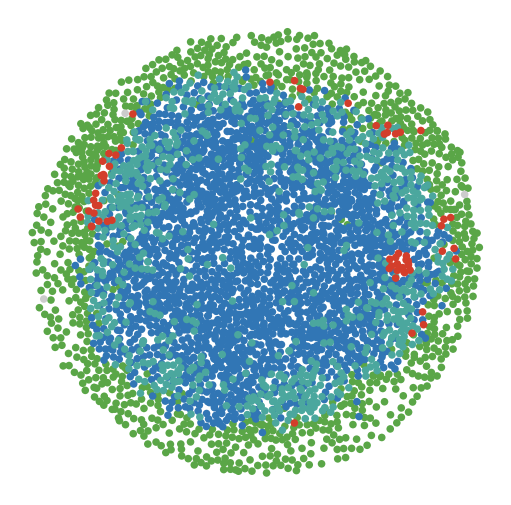

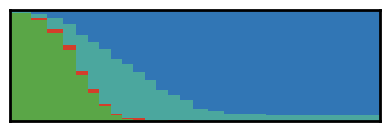

In [245]:
# Display experimental data
filename = f'Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_exp.png'
hist_filename = f'Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_exp.png'

# Scatter fates
fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
exp_result_Z2.col[19].scatter_fates(
    ms=ms, ax=ax, legend=False, thresh=exp_result_Z2.thresh
)
plt.savefig(filename) 

IIF.fate_histogram(data_cond, exp_result_Z2)
plt.savefig(hist_filename) 

In [174]:
# Training on Exp20, testing on the perturbations
exp_results_list = {'Z2': exp_result_Z2, 'X7': exp_result_X7, '20': exp_result_20}

train_configs = [('20', 'B50')]
test_configs  = [('X7', 'B50T30'), ('Z2', 'B50I5'), ('Z2', 'B50M0p5')]

# Common genes (preserving Exp20 order)
common_gene_names   = [g for g in exp_result_20.gene_names
                       if all(g in exp_res.gene_names
                              for exp_res in exp_results_list.values())]


vib_across, avg_preds, predictions, scalers = IIF.run_vib_across_experiments(
    exp_results_list=exp_results_list,
    train_configs=train_configs,
    test_configs=test_configs,
    signal_names= signals,
    gene_names=common_gene_names,
    hyperparam=hyperparam,
    N_run=3,
    model_path_infix = 'model_across_exp',
    output_prefix='vib_meas_exp20_space'
)

  Z2: 35832 B50 cells
  X7: 27206 B50 cells
  20: 30431 B50 cells
  20 B50: 30431 cells
  X7 B50T30: 17007 cells
  Z2 B50I5: 33047 cells
  Z2 B50M0p5: 25892 cells
  20 B50: [1 2 3 4 5 6]
  Total folds: 6

Run 1/3

    Fold 1/6:
done  Loading... 

    Fold 2/6:
done  Loading... 

    Fold 3/6:
done  Loading... 

    Fold 4/6:
done  Loading... 

    Fold 5/6:
done  Loading... 

    Fold 6/6:
      Loading... done
  Total train: 30431 cells
  Loading full model...   X7 B50T30...   Z2 B50I5...   Z2 B50M0p5... 
  Time: 13.9s

Run 2/3

    Fold 1/6:
done  Loading... 

    Fold 2/6:
done  Loading... 

    Fold 3/6:
done  Loading... 

    Fold 4/6:
done  Loading... 

    Fold 5/6:
done  Loading... 

    Fold 6/6:
      Loading... done
  Total train: 30431 cells
  X7 B50T30...   Z2 B50I5...   Z2 B50M0p5... 
  Time: 13.7s

Run 3/3

    Fold 1/6:
done  Loading... 

    Fold 2/6:
done  Loading... 

    Fold 3/6:
done  Loading... 

    Fold 4/6:
done  Loading... 

    Fold 5/6:
done  Loading... 

 

In [175]:
# Reconstruct exp and col objects from avg_preds

exp_objects = {}
col_objects = {}

for (exp_name, cond), avg_pred in avg_preds.items():
    exp_res = exp_results_list[exp_name]
    
    # Create a copy of meta with the correct condition
    meta = copy.deepcopy(exp_res.meta)
    meta.conditions = [cond]
    
    # Create colony and experiment objects
    col, exp = create_experiment(avg_pred, meta, exp_res.feature_names)
    
    col_objects[(exp_name, cond)] = col
    exp_objects[(exp_name, cond)] = exp
    
    print(f"  {exp_name} {cond}: {len(col)} colonies, {len(avg_pred)} cells")

B50, Nbins = 609
  20 B50: 6 colonies, 30431 cells
B50T30, Nbins = 340
  X7 B50T30: 4 colonies, 17007 cells
B50I5, Nbins = 661
  Z2 B50I5: 6 colonies, 33047 cells
B50M0p5, Nbins = 518
  Z2 B50M0p5: 6 colonies, 25892 cells


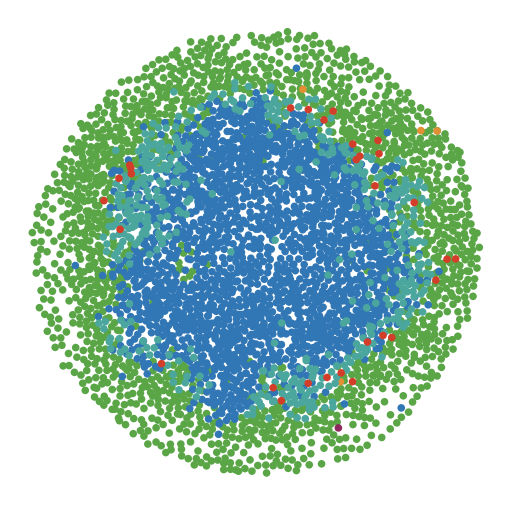

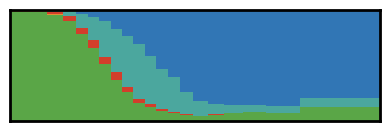

In [240]:
# Display measured signaling predictions based on B50
filename = f'Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_meas.png'
hist_filename = f'Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_meas.png'

# Scatter fates
fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
col_objects[('Z2', 'B50M0p5')][19].scatter_fates(
    ms=ms, ax=ax, legend=False, thresh=exp_result_Z2.thresh
)
plt.savefig(filename) 

IIF.fate_histogram(avg_preds[('Z2', 'B50M0p5')], exp_result_Z2)
plt.savefig(hist_filename) 

In [ ]:
# Make entropy plots
perturb_configs = {
    'MEKi':  dict(perturbing_sigs=['cytopERK'], perturb_mode='inh', percentile=5,  k_nn=5, preserve_signals=['pSMAD1']),
    'IWP2':  dict(perturbing_sigs=['LEF1'],     perturb_mode='inh', percentile=0.1, k_nn=5, preserve_signals=['pSMAD1']),
    'TRULI': dict(perturbing_sigs=['ncYAP'],    perturb_mode='act',  percentile=5,   k_nn=5, preserve_signals=None),
}

# Measured conditions
meas_configs = [
    (exp_result_20, 'B50',     'B50'),
    (exp_result_Z2, 'B50M0p5', 'Z2 MEKi'),
    (exp_result_Z2, 'B50I5',   'Z2 IWP2'),
    (exp_result_X7, 'B50T30',  'X7 TRULI'),

naive_data, naive_data_z, knn_data, knn_data_z = {}, {}, {}, {}

for label, kwargs in perturb_configs.items():
    threshold = IIF.determine_threshold(data_B50_20, **{k: kwargs[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']})
    threshold_smoothed = IIF.determine_threshold(data_smoothed, **{k: kwargs[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']})
    
    naive_data[label], naive_data_z[label] = IIF.create_perturbed_data(
        data_B50_20, exp_result_20.signal_names,
        kwargs['perturbing_sigs'], threshold,
        perturb_mode=kwargs['perturb_mode'], do_naive=True,
        preserve_signals=kwargs['preserve_signals']
    )
    knn_data[label], knn_data_z[label] = IIF.create_perturbed_data(
        data_smoothed, exp_result_20.signal_names,
        kwargs['perturbing_sigs'], threshold_smoothed,
        perturb_mode=kwargs['perturb_mode'], do_naive=False,
        k_nn=kwargs['k_nn'], preserve_signals=kwargs['preserve_signals']
    )


# All datasets to process: (raw_data, z_data, label)
entropy_datasets = (
    [(exp_res.data[exp_res.data['condition'] == cond],
      exp_res.data_z[exp_res.data_z['condition'] == cond], label)
     for exp_res, cond, label in meas_configs] +
    [(naive_data[k],  naive_data_z[k],  f'{label} (naive)') for k, (_, _, label) in zip(perturb_configs, meas_configs[1:])] +
    [(knn_data[k],    knn_data_z[k],    f'{label} (knn)')   for k, (_, _, label) in zip(perturb_configs, meas_configs[1:])]
)

latent_entropy_results = {}

for _, data_cond_z, label in entropy_datasets:
    per_cell, mu_np = IIF.compute_latent_position_entropy(
        vib, data_cond_z,
        signals,
        exp_result_20.gene_names,
        exp_result_20.thresh,
        n_samples=1000
    )
    
    latent_entropy_results[label] = {
        'per_cell': per_cell,
        'L1':       (mu_np[:, 0] - L1mean) / L1std,
        'L2':       (mu_np[:, 1] - L2mean) / L1std,
        'mean':     per_cell.mean()
    }

In [200]:
from scipy.interpolate import RBFInterpolator

# Extrapolate B50 latent entropy
res      = latent_entropy_results['B50']
points   = np.stack([res['L1'], res['L2']], axis=1)
entropy_vals = res['per_cell'].values

# Grid matching latent space
grid_size   = 200
l1_grid     = np.linspace(L1smin, L1smax, grid_size)
l2_grid     = np.linspace(L2smin, L2smax, grid_size)
L1g, L2g    = np.meshgrid(l1_grid, l2_grid)
grid_points = np.stack([L1g.ravel(), L2g.ravel()], axis=1)

# RBF interpolation/extrapolation
rbf          = RBFInterpolator(points, entropy_vals,
                               kernel='thin_plate_spline', smoothing=0.005)
entropy_grid = rbf(grid_points).reshape(grid_size, grid_size)
entropy_grid = np.clip(entropy_grid, 0, np.log2(len(IIF.colmap_fates)))

In [202]:
import matplotlib.colors as mcolors

# Clip RdBu_r
frac_start = 0.2 / 2.2  # = vmin_magnitude / total_range

cmap_clipped = mcolors.LinearSegmentedColormap.from_list(
    'RdBu_r_clipped',
    plt.colormaps['RdBu_r'](np.linspace(frac_start, 1.0, 256))
)

  99.0% inside contours


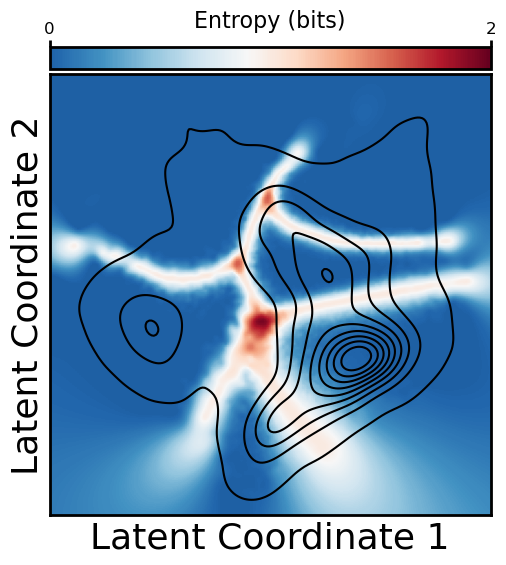

  99.0% inside contours


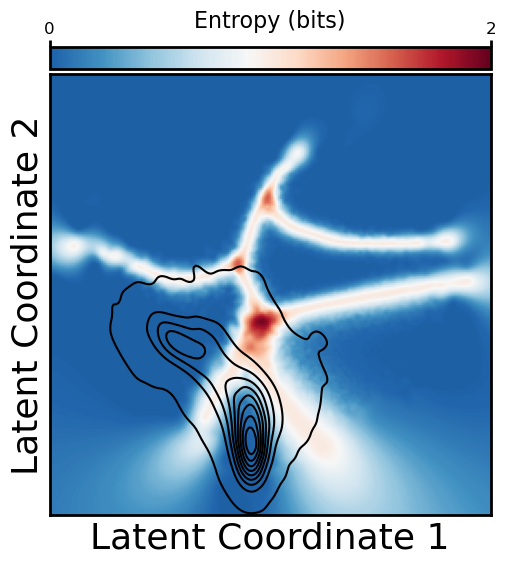

  99.0% inside contours


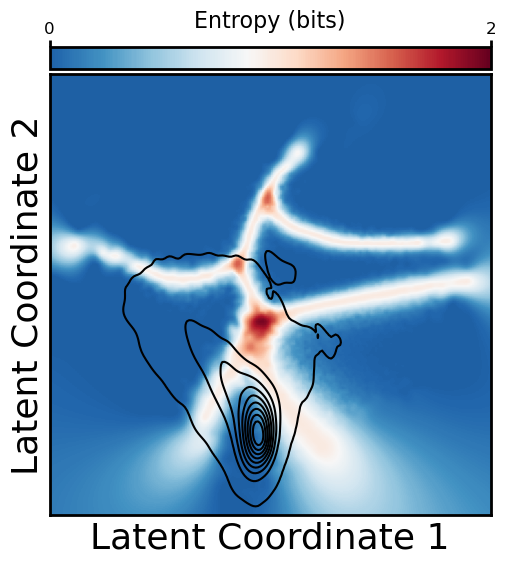

  99.0% inside contours


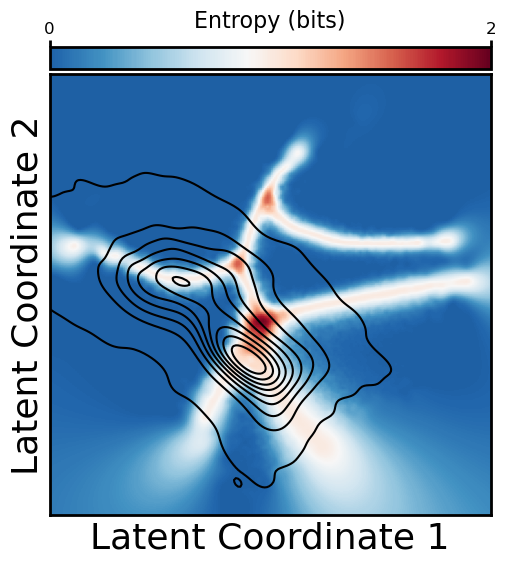

In [204]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

for exp_res, cond, label in meas_configs:
    
    # Encode measured condition
    data_cond_z       = exp_res.data_z[exp_res.data_z['condition'] == cond]
    mu_meas, _        = vib.model.encode(
        torch.FloatTensor(data_cond_z[signals].values)
    )
    mu_meas           = mu_meas.detach().numpy()
    L1_scaled_meas    = (mu_meas[:, 0] - L1mean) / L1std
    L2_scaled_meas    = (mu_meas[:, 1] - L2mean) / L1std

    # Plot
    fig, ax = plt.subplots(figsize=(5, 6))
    im      = ax.imshow(entropy_grid, origin='lower',
                        extent=[L1smin, L1smax, L2smin, L2smax],
                        cmap=cmap_clipped, vmin=0, vmax=2, aspect='auto', zorder=1)

    # Colorbar on top
    divider = make_axes_locatable(ax)
    cax     = divider.append_axes('top', size='5%', pad=0.05)
    cbar    = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label('Entropy (bits)', fontsize=16, labelpad=-4)
    cbar.ax.tick_params(labelsize=12, length=5, width=2, pad=2)
    cbar.set_ticks([0, 2])
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.set_ticks_position('top')
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(sw)

    # Measured KDE
    kde_grid_meas, levels_meas = IIF.kde_on_grid(
        L1_scaled_meas, L2_scaled_meas, L1grid_scaled, L2grid_scaled
    )
    ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_meas,
               levels=levels_meas, colors='black', linewidths=1.5)

    ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
    ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(L1smin, L1smax)
    ax.set_ylim(L2smin, L2smax)
    ax.set_aspect('equal', adjustable='box')
    for spine in ax.spines.values():
        spine.set_linewidth(sw)

    plt.tight_layout(pad=0.5)
    plt.savefig(
        os.path.join(f'Fig5/LS_entropy_kde_{label.replace(" ", "_")}.png'),
        dpi=150, bbox_inches='tight', pad_inches=0.1
    )
    plt.show()
    plt.close()

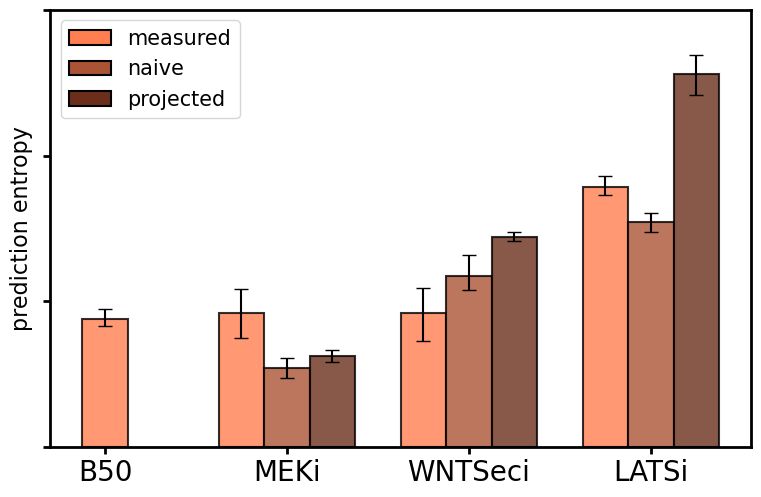

In [234]:
# Plot mean entropy for each predictions
condition_data_dict = {
    'B50':              exp_result_20.data[exp_result_20.data['condition'] == 'B50'],
    'Z2 MEKi':          exp_result_Z2.data[exp_result_Z2.data['condition'] == 'B50M0p5'],
    'Z2 IWP2':          exp_result_Z2.data[exp_result_Z2.data['condition'] == 'B50I5'],
    'X7 TRULI':         exp_result_X7.data[exp_result_X7.data['condition'] == 'B50T30'],
    'Z2 MEKi (naive)':  naive_data['MEKi'],
    'Z2 IWP2 (naive)':  naive_data['IWP2'],
    'X7 TRULI (naive)': naive_data['TRULI'],
    'Z2 MEKi (knn)':    knn_data['MEKi'],
    'Z2 IWP2 (knn)':    knn_data['IWP2'],
    'X7 TRULI (knn)':   knn_data['TRULI'],
}

fig, ax = plot_latent_entropy_comparison(
    latent_entropy_results=latent_entropy_results,
    condition_data_dict=condition_data_dict,
    figsize=(8, 5),
    use_ci=True
)

for spine in ax.spines.values():
    spine.set_linewidth(sw)

ax.tick_params(axis='x', labelsize=fs_ticks, width=sw, length=5)
ax.tick_params(axis='y', labelsize=fs_ticks, width=sw, length=5)
ax.set_yticks([0, 0.3, 0.6, 0.9])
ax.set_yticklabels([]) 

plt.savefig('Fig5/entropy_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

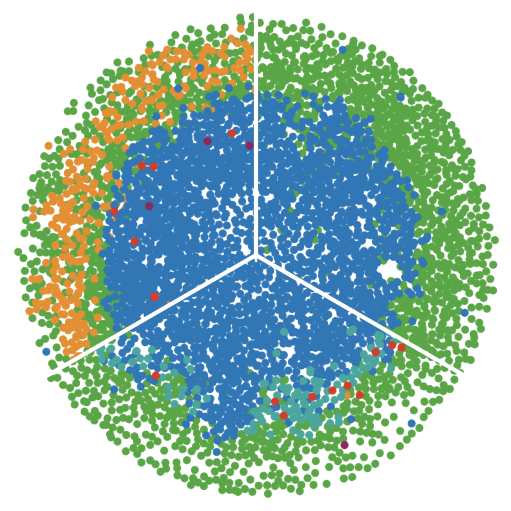

In [223]:
fig, ax = IIF.plot_colony_pie_triplet(
    colony_list=[col_naive_pred[2], col_objects[('Z2', 'B50M0p5')][19], col_knn_pred[2]],
    exp_result_list=[exp_result_20, exp_result_Z2, exp_result_20],
    labels=['', '', ''],
    ms=30,           # matches plot_colony_and_histogram default
    start_angle=90,
    boundary_color='white',
    boundary_lw=3,
    #lim = 375
)

plt.savefig(f'Fig5/three_way_colony_plot_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_naive_knn_meas.png') 

In [235]:
# Training on Exp20 and perturbation
exp_results_list = {'Z2': exp_result_Z2, 'X7': exp_result_X7, '20': exp_result_20}

train_configs = [('20', 'B50'),  ('Z2', 'B50M0p5')]
test_configs  = []

# Common genes (preserving Exp20 order)
common_gene_names   = [g for g in exp_result_20.gene_names
                       if all(g in exp_res.gene_names
                              for exp_res in exp_results_list.values())]


vib_joint, avg_preds_joint, predictions_joint, scalers_joint = IIF.run_vib_across_experiments(
    exp_results_list=exp_results_list,
    train_configs=train_configs,
    test_configs=test_configs,
    signal_names= signals,
    gene_names=common_gene_names,
    hyperparam=hyperparam,
    N_run=3,
    model_path_infix = 'model_joint_MEKi',
    output_prefix='vib_joint_meas_exp20_space'
)

  Z2: 35832 B50 cells
  X7: 27206 B50 cells
  20: 30431 B50 cells
  20 B50: 30431 cells
  Z2 B50M0p5: 25892 cells
  20 B50: [1 2 3 4 5 6]
  Z2 B50M0p5: [19 20 21 22 23 24]
  Total folds: 6

Run 1/3

    Fold 1/6:
done  Training... 

    Fold 2/6:
done  Training... 

    Fold 3/6:
done  Training... 

    Fold 4/6:
done  Training... 

    Fold 5/6:
done  Training... 

    Fold 6/6:
done  Training... 
  Total train: 56323 cells
  Training full model... 
  Time: 105.9s

Run 2/3

    Fold 1/6:
done  Training... 

    Fold 2/6:
done  Training... 

    Fold 3/6:
done  Training... 

    Fold 4/6:
done  Training... 

    Fold 5/6:
done  Training... 

    Fold 6/6:
done  Training... 
  Total train: 56323 cells
  Training full model... 
  Time: 112.8s

Run 3/3

    Fold 1/6:
done  Training... 

    Fold 2/6:
done  Training... 

    Fold 3/6:
done  Training... 

    Fold 4/6:
done  Training... 

    Fold 5/6:
done  Training... 

    Fold 6/6:
done  Training... 
  Total train: 56323 cells
  Trainin

In [236]:
# Reconstruct exp and col objects from avg_preds_joint
exp_objects_joint = {}
col_objects_joint = {}

for (exp_name, cond), avg_pred_joint in avg_preds_joint.items():
    exp_res = exp_results_list[exp_name]
    
    # Create a copy of meta with the correct condition
    meta = copy.deepcopy(exp_res.meta)
    meta.conditions = [cond]
    
    # Create colony and experiment objects
    col, exp = create_experiment(avg_pred_joint, meta, exp_res.feature_names)
    
    col_objects_joint[(exp_name, cond)] = col
    exp_objects_joint[(exp_name, cond)] = exp
    
    print(f"  {exp_name} {cond}: {len(col)} colonies, {len(avg_pred_joint)} cells")

B50, Nbins = 609
  20 B50: 6 colonies, 30431 cells
B50M0p5, Nbins = 518
  Z2 B50M0p5: 6 colonies, 25892 cells


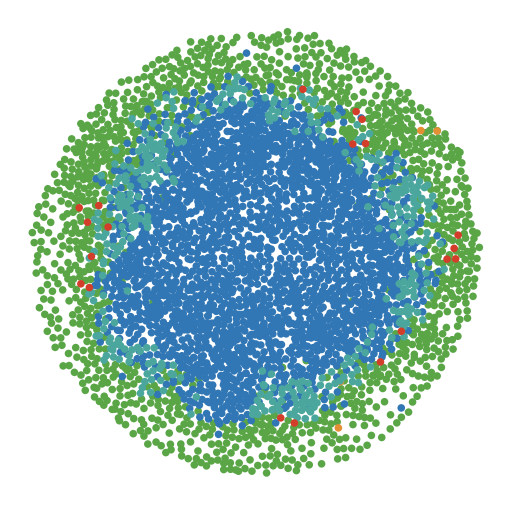

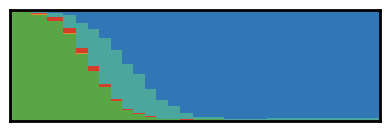

In [241]:
# Display measured signaling predictions based on joint predictions
filename = f'Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_meas_joint.png'
hist_filename = f'Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_meas_joint.png'

# Scatter fates
fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
col_objects_joint[('Z2', 'B50M0p5')][19].scatter_fates(
    ms=ms, ax=ax, legend=False, thresh=exp_result_Z2.thresh
)
plt.savefig(filename) 

IIF.fate_histogram(avg_preds_joint[('Z2', 'B50M0p5')], exp_result_Z2)
plt.savefig(hist_filename) 

  99.0% inside contours
  99.0% inside contours


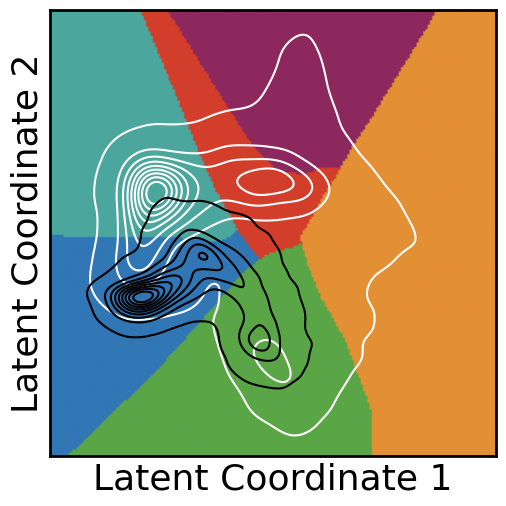

In [256]:
# Encode B50 in joint map
vib_joint_choice = vib_joint[0][0]
model     = vib_joint_choice.model


data_z_B50 = exp_result_20.data_z[exp_result_20.data_z['condition'] == 'B50']
X          = torch.FloatTensor(data_z_B50[signals].values).to(device)

model.eval()
with torch.no_grad():
    mu, _ = model.encode(X)

L1, L2         = mu[:, 0].cpu().numpy(), mu[:, 1].cpu().numpy()
L1mean, L1std  = L1.mean(), L1.std()
L2mean         = L2.mean()
L1_scaled      = (L1 - L1mean) / L1std
L2_scaled      = (L2 - L2mean) / L1std

# Axis limits
marg = 0.5
xlim      = (np.percentile(L1_scaled, 0.1) - marg, np.percentile(L1_scaled, 99.9) + marg)
ylim      = (np.percentile(L2_scaled, 0.1) - marg, np.percentile(L2_scaled, 99.9) + marg)
max_range = max(xlim[1] - xlim[0], ylim[1] - ylim[0])
x_center  = (xlim[0] + xlim[1]) / 2
y_center  = (ylim[0] + ylim[1]) / 2

L1smin, L1smax, L2smin, L2smax = (x_center - max_range/2, x_center + max_range/2,
                                y_center - max_range/2, y_center + max_range/2)

# Grid
L1grid_scaled, L2grid_scaled = np.meshgrid(
    np.linspace(L1smin, L1smax, 200),
    np.linspace(L2smin, L2smax, 200)
)
L1grid_raw = L1grid_scaled * L1std + L1mean
L2grid_raw = L2grid_scaled * L1std + L2mean

# Fate map
with torch.no_grad():
    Y_z   = model.decode(torch.FloatTensor(
        np.stack([L1grid_raw.ravel(), L2grid_raw.ravel()], axis=1)
    ).to(device)).cpu().numpy()

Y_fate      = pd.DataFrame(scalers['20']['Y'].inverse_transform(Y_z), columns=common_gene_names)
fates, _    = IIF.return_fates(Y_fate, thresh=exp_result_20.thresh)
fate_colors = np.array([mcolors.to_rgb(IIF.colmap_fates[f]) for f in fates])
rgb_image   = fate_colors.reshape(200, 200, 3)


# Encode measured perturbation
data_meas_z       = exp_result_Z2.data_z[exp_result_Z2.data_z['condition'] == 'B50M0p5']
X_meas            = torch.FloatTensor(data_meas_z[signals].values).to(device)

with torch.no_grad():
    mu_meas, _ = model.encode(X_meas)
mu_meas = mu_meas.cpu().numpy()

L1_scaled_meas = (mu_meas[:, 0] - L1mean) / L1std
L2_scaled_meas = (mu_meas[:, 1] - L2mean) / L1std


# Plot

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb_image, origin='lower', extent=[L1smin, L1smax, L2smin, L2smax])

kde_grid_b50,  levels_b50  = IIF.kde_on_grid(L1_scaled,      L2_scaled,      L1grid_scaled, L2grid_scaled)
kde_grid_meas, levels_meas = IIF.kde_on_grid(L1_scaled_meas, L2_scaled_meas, L1grid_scaled, L2grid_scaled)

ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_b50,  levels=levels_b50,  colors='white', linewidths=1.5)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_meas, levels=levels_meas, colors='black', linewidths=1.5)

ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
ax.set_xticks([]);  ax.set_yticks([])
ax.set_xlim(L1smin, L1smax);  ax.set_ylim(L2smin, L2smax)
ax.set_aspect('equal', adjustable='box')

for spine in ax.spines.values():
    spine.set_linewidth(sw)

plt.tight_layout(pad=0.5)
plt.savefig('LS_fate_6D_LEF1_inh_ctrl_vs_meas_joint.png', dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()